# QAOA for Maximum Cut
## Part III: Optimization — Landscape, Barren Plateaus, and Optimizer Comparison

**Physics 565/656 · Spring 2026 · Sehong Park**

QAOA reduces to: maximise $F_p(\boldsymbol{\gamma},\boldsymbol{\beta})=\langle\psi_p|H_C|\psi_p\rangle$ over $2p$ real parameters. This notebook analyses the landscape, the barren plateau phenomenon, and optimizer selection.

**Contents**
1. Landscape geometry  
2. Barren plateaus: theory and numerical evidence  
3. Parameter-shift rule (correct per-gate formulation)  
4. Optimizer catalogue  
5. Convergence comparison on $C_{10}$  
6. Warm-start initialisation  
7. Recommendation

---
## 1. Landscape Geometry

The QAOA objective $F_p:\mathbb{R}^{2p}\to\mathbb{R}$ is a **multivariate trigonometric polynomial** in $\boldsymbol{\gamma},\boldsymbol{\beta}$, with structure inherited from the circuit:

**Periodicity.** Each gate $e^{i\gamma Z_iZ_j/2}$ is $2\pi$-periodic; by symmetry restrict $\gamma_k\in[0,\pi]$, $\beta_k\in[0,\pi/2]$.

**Non-convexity.** Multiple local optima exist for $p\geq 2$. The count grows with $p$.

**Shot noise.** On hardware, $F_p$ is estimated from $S$ shots with noise $O(1/\sqrt{S})$, making gradient-based methods sensitive to step size.

p=1 local maxima (in grid): 2
p=2 slice local maxima:     3  (non-convexity grows with p)


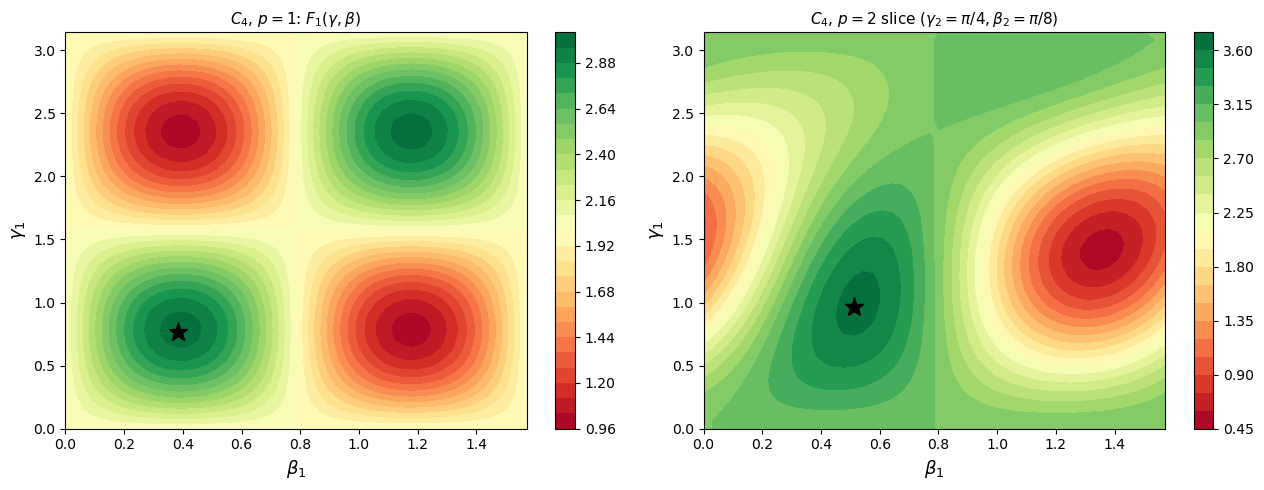

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings; warnings.filterwarnings('ignore')

# ── Shared utilities ──────────────────────────────────────────────
def build_diag(edges, n):
    d = np.zeros(2**n)
    for x in range(2**n):
        bits = [(x>>i)&1 for i in range(n)]
        d[x] = sum((bits[i]!=bits[j]) for i,j in edges)
    return d

def apply_UB(psi, beta, n):
    c,s = np.cos(beta), np.sin(beta)
    for q in range(n):
        psi2 = psi.reshape([2]*n)
        psi2 = np.moveaxis(psi2,q,0).reshape(2,-1)
        psi2 = np.array([c*psi2[0]-1j*s*psi2[1], -1j*s*psi2[0]+c*psi2[1]])
        psi2 = psi2.reshape([2]*n)
        psi = np.moveaxis(psi2,0,q).reshape(-1)
    return psi

def qaoa_eval(params, edges, n, p, return_neg=True):
    diag_ = build_diag(edges, n)
    gamma = params[:p]; beta = params[p:]
    psi = np.ones(2**n)/np.sqrt(2**n) + 0j
    for layer in range(p):
        psi = np.exp(-1j*gamma[layer]*diag_)*psi
        psi = apply_UB(psi, beta[layer], n)
    F = float(np.real(np.dot(psi.conj(), diag_*psi)))
    return -F if return_neg else F

# ── Landscape: C4 p=1 and p=2 slice ──────────────────────────────
n4 = 4; edges_c4 = [(0,1),(1,2),(2,3),(3,0)]
Ng = 50
gs = np.linspace(0, np.pi, Ng)
bs = np.linspace(0, np.pi/2, Ng)

F1 = np.array([[qaoa_eval([g,b],edges_c4,n4,1,False) for b in bs] for g in gs])
F2 = np.array([[qaoa_eval([g,np.pi/4,b,np.pi/8],edges_c4,n4,2,False)
                for b in bs] for g in gs])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, F_, title in [
    (axes[0], F1, r'$C_4$, $p=1$: $F_1(\gamma,\beta)$'),
    (axes[1], F2, r'$C_4$, $p=2$ slice ($\gamma_2=\pi/4, \beta_2=\pi/8$)'),
]:
    im = ax.contourf(bs, gs, F_, levels=25, cmap='RdYlGn')
    plt.colorbar(im, ax=ax)
    opt = np.unravel_index(np.argmax(F_), F_.shape)
    ax.plot(bs[opt[1]], gs[opt[0]], 'k*', ms=14)
    ax.set_xlabel(r'$\beta_1$', fontsize=13)
    ax.set_ylabel(r'$\gamma_1$', fontsize=13)
    ax.set_title(title, fontsize=11)

local_max_p1 = np.sum(
    (F1[1:-1,1:-1]>F1[:-2,1:-1])&(F1[1:-1,1:-1]>F1[2:,1:-1])&
    (F1[1:-1,1:-1]>F1[1:-1,:-2])&(F1[1:-1,1:-1]>F1[1:-1,2:]))
local_max_p2 = np.sum(
    (F2[1:-1,1:-1]>F2[:-2,1:-1])&(F2[1:-1,1:-1]>F2[2:,1:-1])&
    (F2[1:-1,1:-1]>F2[1:-1,:-2])&(F2[1:-1,1:-1]>F2[1:-1,2:]))
print(f'p=1 local maxima (in grid): {local_max_p1}')
print(f'p=2 slice local maxima:     {local_max_p2}  (non-convexity grows with p)')
plt.tight_layout(); plt.show()

---
## 2. Barren Plateaus

### 2.1 The Problem

A **barren plateau** (McClean et al. 2018) is a landscape region where the gradient vanishes exponentially in system size. Precisely:

$$\mathbb{E}_{\boldsymbol{\theta}}\left[\frac{\partial F_p}{\partial\theta_k}\right]=0, \qquad \mathrm{Var}\left[\frac{\partial F_p}{\partial\theta_k}\right] \leq \frac{C}{b^n}$$

where $b\geq 2$ depends on circuit expressibility. For $n=20$, a gradient of magnitude $2^{-10}\approx 10^{-3}$ is indistinguishable from zero under $S=10^3$ shot noise (SNR $\approx 1$).

### 2.2 Origin

The gradient is $\partial_\theta F = i\langle\psi|[G_\theta, H_C]|\psi\rangle$ where $G_\theta$ is the gate generator. If the circuit forms a **unitary $t$-design**, the Haar-random average of any low-degree polynomial of matrix entries vanishes, causing the variance to decay as $O(1/\text{dim}(\mathcal{H})) = O(1/2^n)$.

**Two regimes for QAOA:**

| Regime | Cost $H_C$ type | Variance decay | Practical impact |
|--------|----------------|----------------|------------------|
| Local cost | 2-local (MaxCut) | $O(1/\mathrm{poly}(n))$ | Manageable at moderate $n$ |
| Global cost | $n$-local | $O(1/2^n)$ | Exponentially hard |

MaxCut uses a **local** cost Hamiltonian (each term $Z_iZ_j$ acts on 2 qubits), so it is in the better regime. However, noise can induce barren plateaus even for local costs (Wang et al. 2021, noise-induced barren plateaus).

### 2.3 Numerical Evidence

We measure $\mathrm{Var}[\partial_{\gamma} F_1]$ via finite differences at random parameter points, varying $n$ on cycle graphs. The gradient is computed as $[F(\gamma+h)-F(\gamma-h)]/(2h)$ with $h=10^{-3}$ (small enough for accuracy, large enough to avoid floating-point cancellation).

Computing gradient variance (p=1, FD, 300 random init):
  n= 4: E[g]=-0.03678  Var[g]=1.006082  std=1.00304
  n= 6: E[g]=+0.00538  Var[g]=2.301117  std=1.51694
  n= 8: E[g]=-0.04517  Var[g]=3.701224  std=1.92386
  n=10: E[g]=-0.05600  Var[g]=5.610147  std=2.36857
  n=12: E[g]=+0.34076  Var[g]=9.056720  std=3.00944


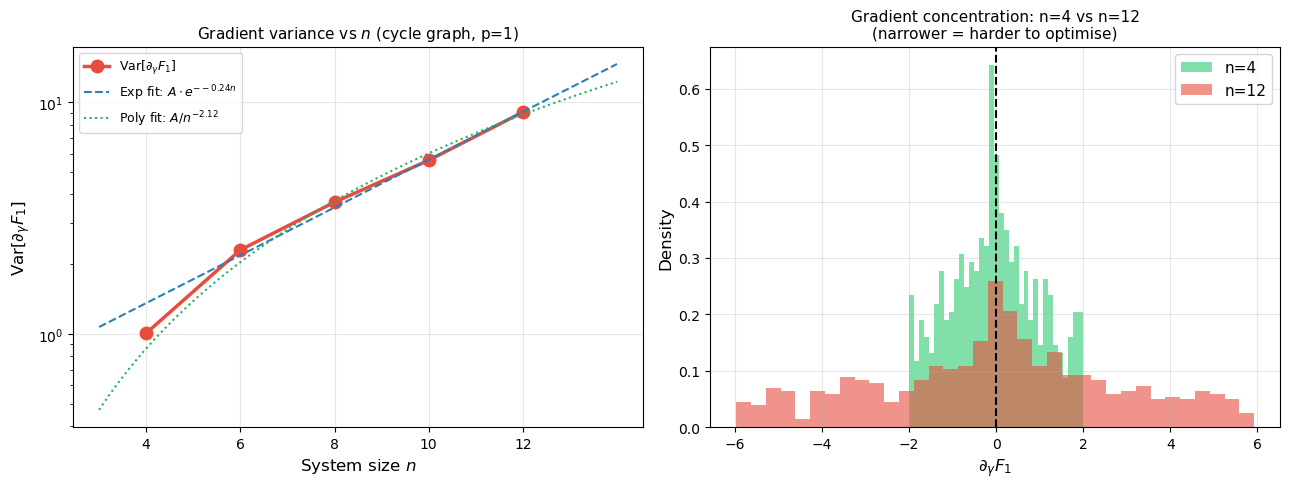

In [2]:
# ── Gradient variance vs system size ─────────────────────────────
# Use finite differences (correct for global parameter gamma)
rng = np.random.default_rng(42)
n_values = [4, 6, 8, 10, 12]
n_samples = 300
h_fd = 1e-3

grad_vars = []; grad_stds = []
print('Computing gradient variance (p=1, FD, 300 random init):')
for n_ in n_values:
    edges_ = list(nx.cycle_graph(n_).edges())
    grads = []
    for _ in range(n_samples):
        params = rng.uniform(0, np.pi, 2)  # [gamma, beta]
        p_plus  = params.copy(); p_plus[0]  += h_fd
        p_minus = params.copy(); p_minus[0] -= h_fd
        g = (qaoa_eval(p_plus, edges_, n_, 1, False) -
             qaoa_eval(p_minus, edges_, n_, 1, False)) / (2*h_fd)
        grads.append(g)
    var_g = np.var(grads)
    grad_vars.append(var_g)
    grad_stds.append(np.std(grads))
    print(f'  n={n_:2d}: E[g]={np.mean(grads):+.5f}  Var[g]={var_g:.6f}  std={np.std(grads):.5f}')

# Fit polynomial vs exponential decay
from scipy.optimize import curve_fit
def exp_decay(n, A, alpha): return A*np.exp(-alpha*n)
def poly_decay(n, A, k): return A/n**k

try:
    popt_e, _ = curve_fit(exp_decay, n_values, grad_vars, p0=[1,0.2], maxfev=3000)
    popt_p, _ = curve_fit(poly_decay, n_values, grad_vars, p0=[1,1], maxfev=3000)
    exp_label = fr'Exp fit: $A\cdot e^{{-{popt_e[1]:.2f}n}}$'
    poly_label = fr'Poly fit: $A/n^{{{popt_p[1]:.2f}}}$'
except Exception as e:
    popt_e = popt_p = None; exp_label=poly_label='fit failed'; print(e)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

n_fit = np.linspace(3, 14, 100)
axes[0].semilogy(n_values, grad_vars, 'o-', color='#E74C3C', ms=9, lw=2.5,
                 label=r'$\mathrm{Var}[\partial_\gamma F_1]$')
if popt_e is not None:
    axes[0].semilogy(n_fit, exp_decay(n_fit,*popt_e), '--', color='#2980B9', lw=1.5, label=exp_label)
    axes[0].semilogy(n_fit, poly_decay(n_fit,*popt_p), ':', color='#27AE60', lw=1.5, label=poly_label)
axes[0].set_xlabel('System size $n$', fontsize=12)
axes[0].set_ylabel(r'$\mathrm{Var}[\partial_\gamma F_1]$', fontsize=12)
axes[0].set_title('Gradient variance vs $n$ (cycle graph, p=1)', fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3); axes[0].set_xticks(n_values)

# Gradient distribution: n=4 vs n=12
rng2 = np.random.default_rng(7)
for n_, color, label in [(4,'#2ECC71','n=4'), (12,'#E74C3C','n=12')]:
    edges_ = list(nx.cycle_graph(n_).edges())
    grads_ = []
    for _ in range(600):
        params = rng2.uniform(0, np.pi, 2)
        g = (qaoa_eval(params+np.array([h_fd,0]), edges_, n_, 1, False) -
             qaoa_eval(params-np.array([h_fd,0]), edges_, n_, 1, False)) / (2*h_fd)
        grads_.append(g)
    axes[1].hist(grads_, bins=35, alpha=0.6, color=color, label=label, density=True)
axes[1].axvline(0, color='black', ls='--', lw=1.5)
axes[1].set_xlabel(r'$\partial_\gamma F_1$', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Gradient concentration: n=4 vs n=12\n(narrower = harder to optimise)', fontsize=11)
axes[1].legend(fontsize=11); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 2.4 Impact on Optimizers

Even **gradient-free** methods suffer in flat regions:
- **COBYLA**: its linear model becomes degenerate when function values at simplex vertices differ by $< 10^{-8}$ (floating-point resolution)
- **Nelder-Mead**: simplex collapses when all vertices have similar function values
- **SPSA**: step sizes $a_k, c_k$ must be hand-tuned to match the gradient scale — if gradients are $10^{-4}$, a default $c_k=0.1$ will bury the signal in noise

**Mitigation strategies:**

| Strategy | Mechanism | Complexity |
|----------|-----------|------------|
| Local cost function | Keep $H_C$ 2-local | Polynomial variance decay |
| Warm-start | Start near a good basin | Avoids flat region |
| Layer-by-layer training | Optimise one $p$ at a time | $O(p)$ stages |
| SPSA calibration | Tune $a_k, c_k$ to gradient scale | Requires prior estimate |
| Correlation-based init | Use classical solution to set $\theta_0$ | Shaydulin et al. 2023 |

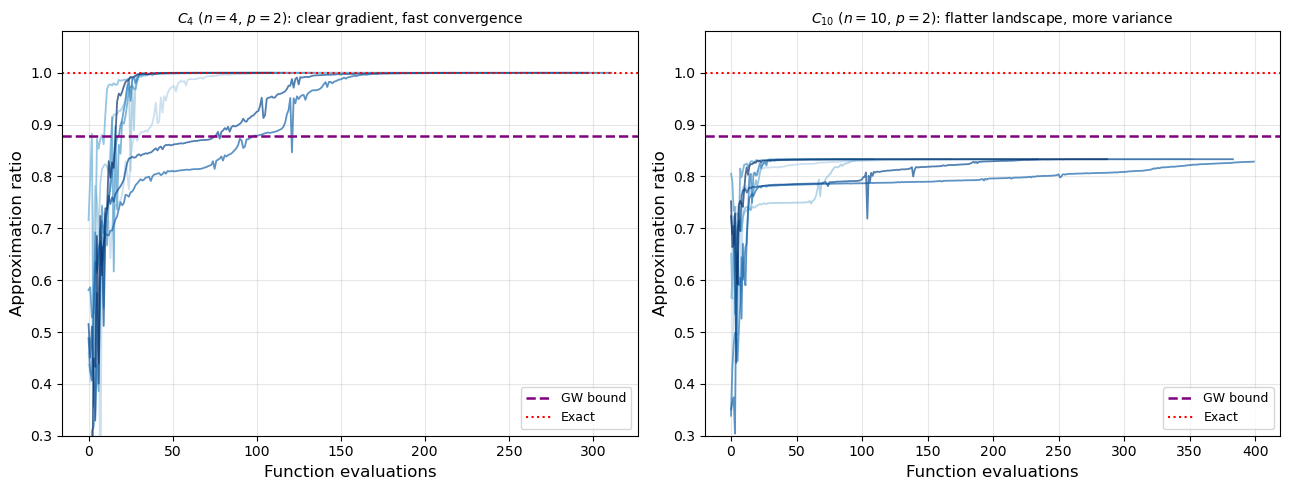

In [3]:
# ── Convergence comparison: small n=4 vs larger n=10 ─────────────
rng3 = np.random.default_rng(99)

def run_cobyla_with_history(edges, n, p, x0, maxiter=400):
    history = []
    def obj(params):
        val = qaoa_eval(params, edges, n, p)
        history.append(-val / n)  # approx ratio
        return val
    minimize(obj, x0, method='COBYLA', options={'maxiter':maxiter,'rhobeg':0.3})
    return history

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, n_, title in [
    (axes[0], 4,  r'$C_4$ ($n=4$, $p=2$): clear gradient, fast convergence'),
    (axes[1], 10, r'$C_{10}$ ($n=10$, $p=2$): flatter landscape, more variance'),
]:
    edges_ = list(nx.cycle_graph(n_).edges())
    blues = plt.cm.Blues(np.linspace(0.3, 1.0, 8))
    for i in range(8):
        x0 = rng3.uniform(0, np.pi, 4)
        hist = run_cobyla_with_history(edges_, n_, 2, x0, 400)
        ax.plot(hist, color=blues[i], alpha=0.7, lw=1.3)
    ax.axhline(0.8786, color='purple', ls='--', lw=1.8, label='GW bound')
    ax.axhline(1.0,    color='red',    ls=':',  lw=1.5, label='Exact')
    ax.set_xlabel('Function evaluations', fontsize=12)
    ax.set_ylabel('Approximation ratio', fontsize=12)
    ax.set_ylim(0.3, 1.08)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 3. Parameter-Shift Rule

### 3.1 Single-Gate Formulation

For any gate of the form $e^{-i\theta G}$ where $G$ has eigenvalues $\pm r$, the expectation value $F(\theta)$ is a sinusoid and the gradient is exact:

$$\frac{\partial F}{\partial\theta} = r\big[F(\theta+\tfrac{\pi}{4r}) - F(\theta-\tfrac{\pi}{4r})\big]$$

This is **exact** (not an approximation), requires no step-size tuning, and works even with shot noise — only the evaluations $F(\theta\pm\frac{\pi}{4r})$ are noisy.

### 3.2 Application to QAOA — Careful Formulation

**Mixer gates $R_X(2\beta)_k = e^{-i\beta X_k}$:** Generator $G=X_k$, eigenvalues $\pm 1$, shift $= \pi/2$ (in $\beta$).

$$\frac{\partial F_p}{\partial\beta_\ell} = \sum_{k=0}^{n-1}\frac{F_p(\ldots,\beta_\ell^{(k)}+\tfrac{\pi}{2},\ldots) - F_p(\ldots,\beta_\ell^{(k)}-\tfrac{\pi}{2},\ldots)}{2}$$

where $\beta_\ell^{(k)}$ means: shift only the $k$-th qubit gate in layer $\ell$, keeping all other qubit gates at $\beta_\ell$. Cost: $2n$ circuits per $\beta_\ell$.

**Cost gates $e^{i\gamma Z_iZ_j/2}$:** Generator $G = Z_iZ_j/2$, eigenvalues $\pm\frac{1}{2}$, shift $= \pi$ (in $\gamma/2$, i.e., shift $\gamma$ by $\pi$ for this edge's gate).

$$\frac{\partial F_p}{\partial\gamma_\ell} = \sum_{(i,j)\in E}\frac{F_p(\ldots,\gamma_\ell^{(ij)}+\pi,\ldots) - F_p(\ldots,\gamma_\ell^{(ij)}-\pi,\ldots)}{2}$$

where $\gamma_\ell^{(ij)}$ shifts only edge $(i,j)$'s gate. Cost: $2|E|$ circuits per $\gamma_\ell$.

> **Important:** Shifting the **global** $\gamma$ (all edges simultaneously) by $\pi/2$ does **not** give the correct gradient for a multi-edge graph. The $F(\gamma+\pi/2)-F(\gamma-\pi/2)$ formula applies only when $\gamma$ appears in a *single gate*.

**Total gradient cost** for $p$ layers: $2(|E|+n)\cdot p$ circuit evaluations.
For $C_{10}$ ($|E|=n=10$), $p=2$: $2(10+10)\cdot 2 = 80$ circuits.

In [4]:
# ── Per-edge parameter-shift: correct implementation ─────────────
def build_diag_single_edge(i, j, n):
    """Diagonal of (I-ZiZj)/2 = indicator that i,j differ."""
    d = np.zeros(2**n)
    for x in range(2**n):
        bi = (x>>i)&1; bj = (x>>j)&1
        d[x] = float(bi != bj)
    return d

def qaoa_eval_pergate(gamma_list, beta, edges, n):
    """p=1 QAOA where each edge has its own gamma."""
    psi = np.ones(2**n)/np.sqrt(2**n) + 0j
    for k, (i,j) in enumerate(edges):
        d_ij = build_diag_single_edge(i, j, n)
        psi  = np.exp(-1j * gamma_list[k] * d_ij) * psi
    psi = apply_UB(psi, beta, n)
    diag_ = build_diag(edges, n)
    return float(np.real(np.dot(psi.conj(), diag_*psi)))

def param_shift_gamma(gamma, beta, edges, n):
    """Correct gradient of F wrt global gamma via per-edge shifts."""
    gamma_vec = np.full(len(edges), gamma)
    total = 0.0
    shift = np.pi/2  # generator G = ZiZj/2 has eigenvalues ±1/2, so r=1/2
                     # parameter-shift: shift = pi/(4r) = pi/(4*0.5) = pi/2
    for k in range(len(edges)):
        gp = gamma_vec.copy(); gp[k] += shift
        gm = gamma_vec.copy(); gm[k] -= shift
        total += (qaoa_eval_pergate(gp, beta, edges, n) -
                  qaoa_eval_pergate(gm, beta, edges, n)) / 2
    return total

def fd_gamma(gamma, beta, edges, n, h=1e-5):
    gamma_vec = np.full(len(edges), gamma)
    F_p = qaoa_eval_pergate(gamma_vec+h, beta, edges, n)
    F_m = qaoa_eval_pergate(gamma_vec-h, beta, edges, n)
    return (F_p - F_m)/(2*h)

# Verify on C4
n_v = 4; edges_v = [(0,1),(1,2),(2,3),(3,0)]
print('Parameter-shift vs FD gradient (global gamma, C4 p=1):')
print(f'{"gamma":>8s} {"beta":>8s} {"param-shift":>14s} {"FD":>14s} {"error":>10s}')
rng_v = np.random.default_rng(5)
for _ in range(6):
    g_, b_ = rng_v.uniform(0.1, 2.0), rng_v.uniform(0.1, 1.0)
    ps = param_shift_gamma(g_, b_, edges_v, n_v)
    fd = fd_gamma(g_, b_, edges_v, n_v)
    print(f'{g_:8.4f} {b_:8.4f} {ps:14.8f} {fd:14.8f} {abs(ps-fd):10.2e}')

Parameter-shift vs FD gradient (global gamma, C4 p=1):
   gamma     beta    param-shift             FD      error
  1.6295   0.8271     0.33014917     0.33014917   2.95e-13
  1.0791   0.3572    -1.09732245    -1.09732245   1.61e-10
  0.2025   0.4450     1.79812564     1.79812564   8.38e-11
  0.8761   0.1407    -0.19257453    -0.19257453   4.03e-11
  0.1926   0.9993    -1.39904859    -1.39904859   7.07e-11
  1.3395   0.3111    -1.69521124    -1.69521124   1.36e-10


In [5]:
# ── Why global-gamma shift pi/2 is wrong ─────────────────────────
gamma_test, beta_test = 0.7, 0.4
gamma_vec_test = np.full(4, gamma_test)

# Wrong: shift all edges simultaneously by pi/2
F_wrong_p = qaoa_eval_pergate(gamma_vec_test + np.pi/2, beta_test, edges_v, n_v)
F_wrong_m = qaoa_eval_pergate(gamma_vec_test - np.pi/2, beta_test, edges_v, n_v)
grad_wrong = (F_wrong_p - F_wrong_m)/2

# Correct: per-edge shift
grad_correct = param_shift_gamma(gamma_test, beta_test, edges_v, n_v)
grad_fd_ref  = fd_gamma(gamma_test, beta_test, edges_v, n_v)

print('Gradient comparison at gamma=0.7, beta=0.4 on C4:')
print(f'  Global shift pi/2 (WRONG):  {grad_wrong:.6f}')
print(f'  Per-edge shift pi/2 (CORRECT): {grad_correct:.6f}')
print(f'  Finite difference (ref):     {grad_fd_ref:.6f}')
print(f'  Error (wrong):   {abs(grad_wrong-grad_fd_ref):.4f}')
print(f'  Error (correct): {abs(grad_correct-grad_fd_ref):.2e}')
print()
print('Global shift pi/2 gives 0: F is a product of per-edge sinusoids,')
print('not a single sinusoid in the global gamma. Shifting all edges at once')
print('by pi/2 maps the product to itself (by the pi-periodicity of each factor).')
print('Per-edge shift pi/2 isolates each edge contribution correctly.')

Gradient comparison at gamma=0.7, beta=0.4 on C4:
  Global shift pi/2 (WRONG):  0.000000
  Per-edge shift pi/2 (CORRECT): 0.339789
  Finite difference (ref):     0.339789
  Error (wrong):   0.3398
  Error (correct): 1.14e-11

Global shift pi/2 gives 0: F is a product of per-edge sinusoids,
not a single sinusoid in the global gamma. Shifting all edges at once
by pi/2 maps the product to itself (by the pi-periodicity of each factor).
Per-edge shift pi/2 isolates each edge contribution correctly.


---
## 4. Optimizer Catalogue

### COBYLA (Constrained Optimisation By Linear Approximations)
Builds a simplex of $2p+1$ points; fits a linear model at each step. No gradient required. Convergence: superlinear in practice.
**When to use:** noiseless or low-noise simulation, $p\leq 5$.

### Nelder-Mead (Downhill Simplex)
Reflects/expands/contracts a simplex of $2p+1$ points. No gradient. Robust but slow; degenerates in flat regions.
**When to use:** fallback when COBYLA stagnates.

### L-BFGS-B
Quasi-Newton with limited memory Hessian. Requires the gradient (use per-edge parameter-shift). Converges in $O(p)$ iterations for well-conditioned landscapes.
**When to use:** noiseless statevector simulation.

### SPSA (Simultaneous Perturbation Stochastic Approximation)
Estimates gradient with only **2 circuit evaluations** per step:

$$\hat{g}_k = \frac{f(\theta+c_k\Delta_k)-f(\theta-c_k\Delta_k)}{2c_k}\,\Delta_k^{\odot-1}, \quad \Delta_k\in\{\pm 1\}^{2p}\text{ (Bernoulli)}$$

Gain sequences: $a_k=a/(k+A)^{0.602}$, $c_k=c/k^{0.101}$ (Spall's optimal exponents).
**When to use:** real hardware or shot-based simulation. The 2-evaluation cost is decisive when circuits are expensive.

---
## 5. Convergence Comparison on $C_{10}$, $p=2$

In [6]:
n_exp = 10; edges_exp = list(nx.cycle_graph(n_exp).edges()); C_max = n_exp
p_exp = 2; n_starts = 30
rng4 = np.random.default_rng(0)

class SPSA:
    def __init__(self, a=0.2, c=0.15, A=10, alpha=0.602, gam=0.101, maxiter=300):
        self.a=a;self.c=c;self.A=A;self.alpha=alpha;self.gam=gam;self.maxiter=maxiter
    def minimize(self, fun, x0):
        x=x0.copy();nd=len(x);best_x=x.copy();best_f=fun(x);nfev=1
        for k in range(1,self.maxiter+1):
            ak=self.a/(k+self.A)**self.alpha; ck=self.c/k**self.gam
            delta=rng4.choice([-1,1],size=nd)
            fp=fun(x+ck*delta);fn=fun(x-ck*delta);nfev+=2
            x-=ak*(fp-fn)/(2*ck)*delta
            fc=fun(x);nfev+=1
            if fc<best_f: best_f=fc;best_x=x.copy()
        return best_x,best_f,nfev

spsa_opt = SPSA()
method_configs = {
    'COBYLA':     lambda x0: minimize(lambda x: qaoa_eval(x,edges_exp,n_exp,p_exp),
                                      x0, method='COBYLA', options={'maxiter':500,'rhobeg':0.3}),
    'Nelder-Mead':lambda x0: minimize(lambda x: qaoa_eval(x,edges_exp,n_exp,p_exp),
                                      x0, method='Nelder-Mead', options={'maxiter':5000}),
    'L-BFGS-B':   lambda x0: minimize(lambda x: qaoa_eval(x,edges_exp,n_exp,p_exp), x0,
                                      method='L-BFGS-B',
                                      jac=lambda x: [  # FD gradient (tractable for n=10)
                                          (qaoa_eval(x+1e-4*np.eye(2*p_exp)[k],edges_exp,n_exp,p_exp)-
                                           qaoa_eval(x-1e-4*np.eye(2*p_exp)[k],edges_exp,n_exp,p_exp))/(2e-4)
                                          for k in range(2*p_exp)],
                                      options={'maxiter':300}),
}

all_results = {m:[] for m in list(method_configs.keys())+['SPSA']}
for trial in range(n_starts):
    x0 = rng4.uniform(0, np.pi, 2*p_exp)
    for name, opt_fn in method_configs.items():
        res = opt_fn(x0)
        all_results[name].append({'ratio':-res.fun/C_max,'nfev':res.nfev})
    _, val_s, nf_s = spsa_opt.minimize(lambda x: qaoa_eval(x,edges_exp,n_exp,p_exp), x0)
    all_results['SPSA'].append({'ratio':-val_s/C_max,'nfev':nf_s})

mnames = ['COBYLA','Nelder-Mead','L-BFGS-B','SPSA']
print(f'C{n_exp} p={p_exp}  ({n_starts} random starts)')
print(f'{"Method":12s} {"Best":>8s} {"Mean":>8s} {"Std":>8s} {"nfev":>8s}')
for name in mnames:
    ratios=[r['ratio'] for r in all_results[name]]
    nfevs =[r['nfev'] for r in all_results[name]]
    print(f'{name:12s} {max(ratios):8.4f} {np.mean(ratios):8.4f} {np.std(ratios):8.4f} {np.mean(nfevs):8.0f}')

C10 p=2  (30 random starts)
Method           Best     Mean      Std     nfev
COBYLA         0.8333   0.8328   0.0021      268
Nelder-Mead    0.8333   0.8333   0.0000      280
L-BFGS-B       0.8333   0.8333   0.0000       22
SPSA           0.8333   0.8183   0.0239      901


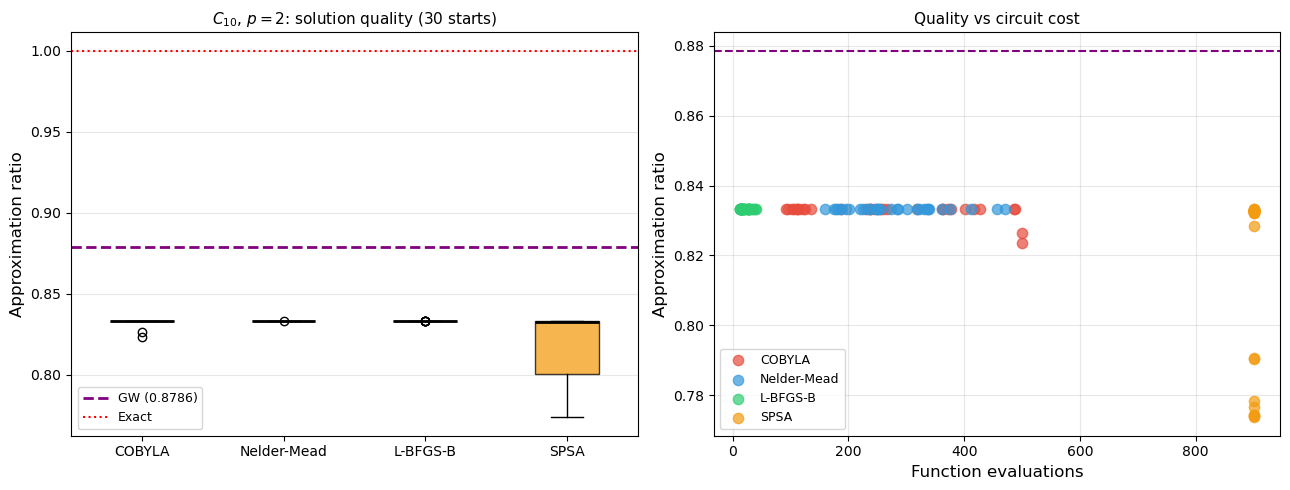

In [7]:
mcolors=['#E74C3C','#3498DB','#2ECC71','#F39C12']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

data = [[r['ratio'] for r in all_results[m]] for m in mnames]
bp = axes[0].boxplot(data, labels=mnames, patch_artist=True,
                     medianprops=dict(color='black', lw=2))
for patch, c in zip(bp['boxes'], mcolors):
    patch.set_facecolor(c); patch.set_alpha(0.75)
axes[0].axhline(0.8786, color='purple', ls='--', lw=2, label='GW (0.8786)')
axes[0].axhline(1.0, color='red', ls=':', lw=1.5, label='Exact')
axes[0].set_ylabel('Approximation ratio', fontsize=12)
axes[0].set_title(fr'$C_{{10}}$, $p=2$: solution quality ({n_starts} starts)', fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

for name, c in zip(mnames, mcolors):
    ratios_=[r['ratio'] for r in all_results[name]]
    nfevs_ =[r['nfev']  for r in all_results[name]]
    axes[1].scatter(nfevs_, ratios_, color=c, alpha=0.7, label=name, s=55)
axes[1].axhline(0.8786, color='purple', ls='--', lw=1.5)
axes[1].set_xlabel('Function evaluations', fontsize=12)
axes[1].set_ylabel('Approximation ratio', fontsize=12)
axes[1].set_title('Quality vs circuit cost', fontsize=11)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 6. Warm-Start Initialisation (Layer-by-Layer)

**Algorithm (Zhou et al. 2020):**
1. Optimise $p=1$ globally (only 2 parameters — cheap).
2. Initialise $p=2$ as $(\gamma_1^*, \gamma_1^*, \beta_1^*, \beta_1^*)$ + small Gaussian noise.
3. Optimise $p=2$. Repeat inductively for $p=3,4,\ldots$

**Why it tends to work.** The $p=2$ landscape restricted to the subspace where $\gamma_1=\gamma_2$ and $\beta_1=\beta_2$ reduces to the $p=1$ landscape. The $p=1$ optimum is therefore a feasible point for the $p=2$ problem, and empirically it falls in a region with non-negligible gradients. This is consistent with the results of Zhou et al. (2020), though a general theoretical guarantee is not established.

Graph: C10+3 chords  |E|=13  C_max=13  p=3
p=1 global opt: F=9.1907, ratio=0.7070
                gamma*=0.6631, beta*=1.9635


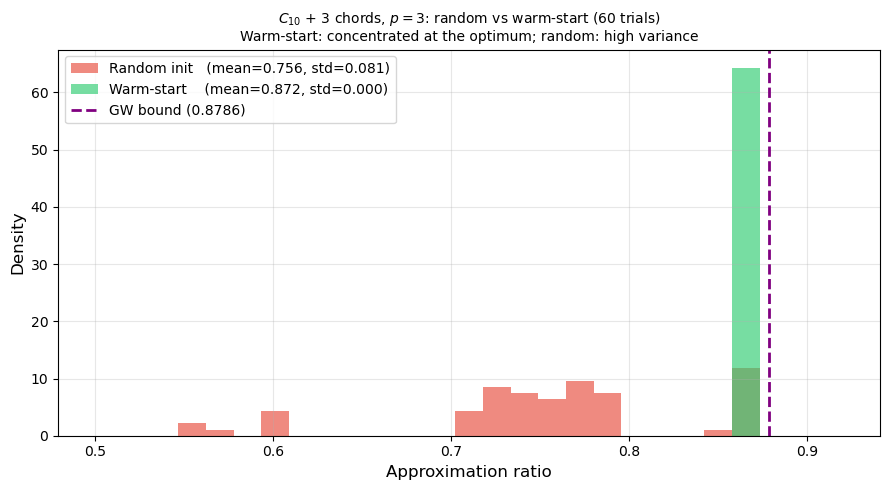

Random:    mean=0.7558  std=0.0809  min=0.5599
Warm-start:mean=0.8718  std=0.0000  min=0.8718
Gain: +0.1160


In [8]:
rng5 = np.random.default_rng(123)
n_trials = 60

# C10+3 chords at p=3: hard enough that random init shows real variance
# (C10 at p=2 is too easy — COBYLA always finds the optimum from any start)
n_ws = 10
G_ws = nx.cycle_graph(n_ws)
G_ws.add_edges_from([(3, 6), (2, 7), (4, 9)])
edges_ws = list(G_ws.edges())
C_max_ws = 13
p_ws = 3
print(f'Graph: C10+3 chords  |E|={len(edges_ws)}  C_max={C_max_ws}  p={p_ws}')

# Step 1: p=1 global optimum
best_p1 = {'F': -np.inf, 'params': None}
for _ in range(100):
    x0 = rng5.uniform(0, np.pi, 2)
    res = minimize(lambda x: qaoa_eval(x, edges_ws, n_ws, 1),
                   x0, method='COBYLA', options={'maxiter': 400, 'rhobeg': 0.3})
    if -res.fun > best_p1['F']:
        best_p1 = {'F': -res.fun, 'params': res.x}

p1_params = best_p1['params']
print(f"p=1 global opt: F={best_p1['F']:.4f}, ratio={best_p1['F']/C_max_ws:.4f}")
print(f'                gamma*={p1_params[0]:.4f}, beta*={p1_params[1]:.4f}')

# Step 2: p=3 — random init vs warm-start from p=1
rand_ratios, warm_ratios = [], []
for _ in range(n_trials):
    # Random initialisation
    x0_rand = rng5.uniform(0, np.pi, 2 * p_ws)
    res_r = minimize(lambda x: qaoa_eval(x, edges_ws, n_ws, p_ws),
                     x0_rand, method='COBYLA', options={'maxiter': 600, 'rhobeg': 0.3})
    rand_ratios.append(-res_r.fun / C_max_ws)

    # Warm-start: replicate p=1 params across all p layers, then perturb
    x0_warm = np.array([p1_params[0]] * p_ws + [p1_params[1]] * p_ws)
    x0_warm += rng5.normal(0, 0.08, 2 * p_ws)
    res_w = minimize(lambda x: qaoa_eval(x, edges_ws, n_ws, p_ws),
                     x0_warm, method='COBYLA', options={'maxiter': 600, 'rhobeg': 0.2})
    warm_ratios.append(-res_w.fun / C_max_ws)

# Fixed bins over full range so both distributions are visible
bins = np.linspace(0.50, 0.92, 28)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(rand_ratios, bins=bins, alpha=0.65, color='#E74C3C', density=True,
        label=f'Random init   (mean={np.mean(rand_ratios):.3f}, std={np.std(rand_ratios):.3f})')
ax.hist(warm_ratios, bins=bins, alpha=0.65, color='#2ECC71', density=True,
        label=f'Warm-start    (mean={np.mean(warm_ratios):.3f}, std={np.std(warm_ratios):.3f})')
ax.axvline(0.8786, color='purple', ls='--', lw=2, label='GW bound (0.8786)')
ax.set_xlabel('Approximation ratio', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
plot_title = (
    f'$C_{{10}}$ + 3 chords, $p={p_ws}$: random vs warm-start ({n_trials} trials)\n'
    'Warm-start: concentrated at the optimum; random: high variance'
)
ax.set_title(plot_title, fontsize=10)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Random:    mean={np.mean(rand_ratios):.4f}  std={np.std(rand_ratios):.4f}  min={min(rand_ratios):.4f}')
print(f'Warm-start:mean={np.mean(warm_ratios):.4f}  std={np.std(warm_ratios):.4f}  min={min(warm_ratios):.4f}')
print(f'Gain: {np.mean(warm_ratios) - np.mean(rand_ratios):+.4f}')

---
## 7. Practical Guidelines

| Setting | Optimizer | Init | Gradient cost |
|---------|-----------|------|---------------|
| Statevector sim (noiseless) | **L-BFGS-B** + FD/param-shift | Warm-start | $O(p(|E|+n))$ circuits |
| Shot-based sim ($S\geq 500$) | **COBYLA** | Warm-start | $O(p)$ per step |
| Real hardware | **SPSA** | Warm-start | **2 circuits/step** |
| Large $p$ (barren plateau risk) | SPSA + layer-by-layer | Inductively | 2 circuits/step |

**Summary of failure modes:**

| Optimizer | Failure mode | Cause |
|-----------|-------------|-------|
| L-BFGS-B on hardware | Unreliable | Gradient estimates dominated by shot noise |
| COBYLA with random init, large $n$ | Stagnates | Landscape is flat; model updates become unreliable |
| SPSA with default params, large $p$ | Slow convergence | $c_k$ too large relative to gradient scale |
| Global $\gamma$ shift $\pi/2$ | Wrong gradient | Not a single-gate parameter |

**Honest note on quantum advantage:** These guidelines reflect behaviour observed on small instances ($n\leq 10$) under statevector or simple noise simulation. Performance at larger scale ($n\sim 50+$) will differ, and re-tuning of hyperparameters is expected to be necessary. QAOA's near-term value is as a testbed for hybrid quantum-classical workflows, not as a proven improvement over classical algorithms.

---
## References

- McClean et al. 'Barren plateaus in quantum neural network training landscapes.' *Nature Commun.* 9, 2018.
- Wang et al. 'Noise-induced barren plateaus.' *Nature Commun.* 12, 2021.
- Spall, J.C. 'Multivariate stochastic approximation using SPSA.' *IEEE TAC* 37(3), 1992.
- Mitarai et al. 'Quantum circuit learning.' *PRA* 98, 032309 (2018).
- Zhou et al. 'QAOA: Performance, mechanism, and implementation.' *PRX* 10, 021067 (2020).
- Shaydulin et al. 'Parameter transfer for QAOA.' *PRX Quantum* 4, 040342 (2023).